In [1]:
from tqdm.notebook import tqdm
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import networkx as nx

from neurodsp.spectral import compute_spectrum
from timescales.fit import PSD
from timescales.plts import set_default_rc
from ad_organoids.spectral import compute_spectra_windows
from ad_organoids.io import load_windows

set_default_rc()

# 02. Computing and Fitting Spectra

This notebook preprocess raw signals and computes spectra for the MEA array. The results are saved out for future processing.

In [2]:
# Paths
dirpath = '/home/rphammonds/projects/ad_organoids'
signal_path = f'{dirpath}/signals/plate4/plate4_midpoint_00'
meta_path = f'{dirpath}/data/plate4/meta.json'
out_path = f'{dirpath}/spectra/plate4/plate4_midpoint_00/welch'

# Load meta data
with open(meta_path) as json_file:
    meta = json.load(json_file)
fs = meta['fs'] * 1000

## Preprocessing

1. Notch filter to account for line noise
2. Graph clustering to remove rogue electrodes

In [3]:
from scipy import signal

def notch_filter(sig, fs):
    # Notch filter for 60 Hz line noise
    b, a = signal.iirnotch(60.0, 120.0, fs)
    return signal.filtfilt(b, a, sig)

def cluster_graph(sig, return_graph=False):
    
    # Flatten to 2d
    sig = sig.reshape(-1, sig.shape[-1])
    
    # Weight edges with correlation coefficients
    corrs = np.corrcoef(sig)

    # Create graph
    G = nx.Graph(corrs)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    # Take mean of the 3/4 of most connected nodes
    n_electrodes = 12
    coeffs = np.array(list(nx.clustering(G, weight='weight').values()))
    inds = np.argsort(coeffs)[-n_electrodes:]
    
    if return_graph:
        return G, coeffs
    
    return sig[inds].mean(axis=0)

1. A notch filter remove line noise.

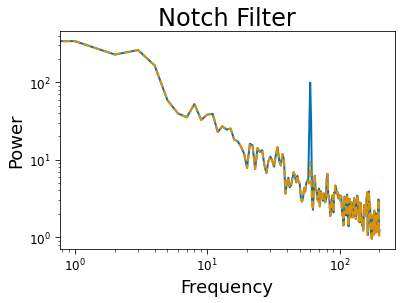

In [4]:
sig = load_windows(signal_path, list(range(10)))[:, 0, 0, 0, 0]
sig_filt = notch_filter(sig, fs)

f0, p0 = compute_spectrum(sig, fs, f_range=(0, 200))
f1, p1 = compute_spectrum(sig_filt, fs, f_range=(0, 200))

# Plot
plt.figure(figsize=(6, 4))
plt.loglog(f0, p0.mean(axis=0))
plt.loglog(f1, p1.mean(axis=0), ls='--')
plt.title('Notch Filter')
plt.xlabel('Frequency')
plt.ylabel('Power');

2. The graph below represents one well of 16 electrodes. The top 14 most connected nodes are used for subsequent analysis.

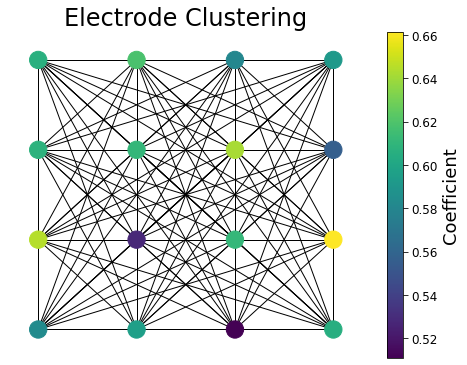

In [5]:
# Compute graph
sig = load_windows(signal_path, 0)[0, 0]
G, coeffs = cluster_graph(sig, return_graph=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Electrode Clustering')
nx.draw(G, {i: (i%4, i//4) for i in G.nodes()}, ax, node_color=coeffs)
norm_cmap = plt.cm.colors.Normalize(vmin=min(coeffs), vmax=max(coeffs))
plt.colorbar(plt.cm.ScalarMappable(norm=norm_cmap), label='Coefficient');

## Compute Spectra

Use Welch's method to compute spectra across 5s windows. Spectra ar computed using a 100th order autoregressive (AR) model. Since the frequency range of interest is limited to 0-1000 Hertz, the signals are downsampled from 12.5 kHz to 2 khz. This allows for faster AR coefficient solutions.

In [6]:
# Combine 5 npz files (1 second each) per window
nperwindow = 5

apply_funcs = [
    ('all', lambda sig : notch_filter(sig, 2000)),
    ('wells', cluster_graph)
]

freqs, powers = compute_spectra_windows(
    signal_path, fs, nperwindow, n_resample=2000, apply_funcs=apply_funcs,
    out_dir=out_path, progress=tqdm, avg_type='median'
)

  0%|          | 0/59 [00:00<?, ?it/s]

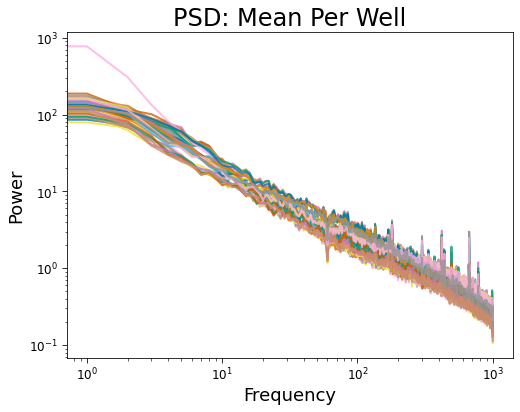

In [7]:
# Plot all wells, taking the mean across windows
plt.figure(figsize=(8, 6))

nrows = 6
ncols = 8

for i in range(nrows):
    for j in range(ncols):
        plt.loglog(freqs, powers[:, i, j].mean(axis=0),
                   alpha=.8)
        
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('PSD: Mean Per Well');

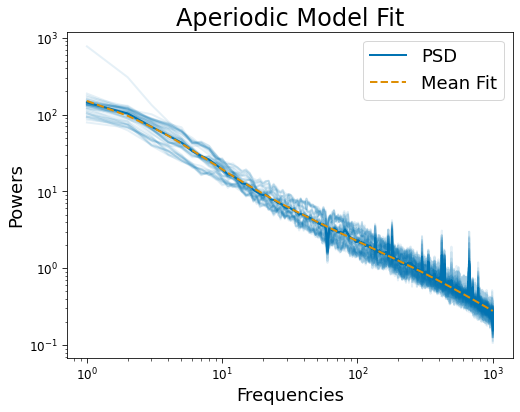

In [8]:
# Fit spectra
psd = PSD(freqs=freqs, powers=np.mean(powers, axis=0).reshape(-1, 1001))
psd.fit(ap_mode='double', method='cauchy', n_resample=500)
psd.plot()